In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("dataset.csv")

In [4]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y
3,lp001006,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y
4,lp001008,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y


In [5]:
df.shape

(614, 13)

In [6]:
df.columns

Index(['loan_id', 'gender', 'married', 'dependents', 'education',
       'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            614 non-null    object 
 1   gender             601 non-null    object 
 2   married            611 non-null    object 
 3   dependents         599 non-null    object 
 4   education          614 non-null    object 
 5   self_employed      582 non-null    object 
 6   applicantincome    614 non-null    int64  
 7   coapplicantincome  614 non-null    float64
 8   loanamount         592 non-null    float64
 9   loan_amount_term   600 non-null    float64
 10  credit_history     564 non-null    float64
 11  property_area      614 non-null    object 
 12  loan_status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
df.describe()

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
df.isnull().sum()

loan_id               0
gender               13
married               3
dependents           15
education             0
self_employed        32
applicantincome       0
coapplicantincome     0
loanamount           22
loan_amount_term     14
credit_history       50
property_area         0
loan_status           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

Approved and Rejected Loans

In [12]:
df["loan_status"].value_counts()

loan_status
y    422
n    192
Name: count, dtype: int64

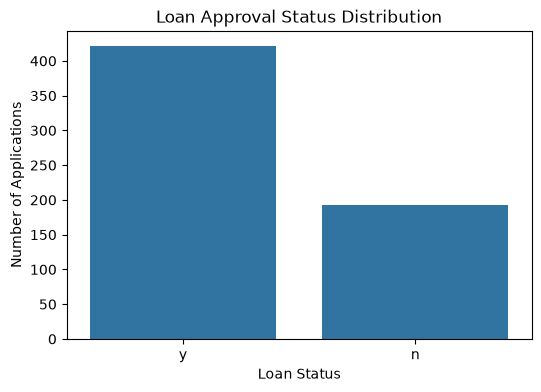

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="loan_status")

plt.title("Loan Approval Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

Credit History vs Loan Status

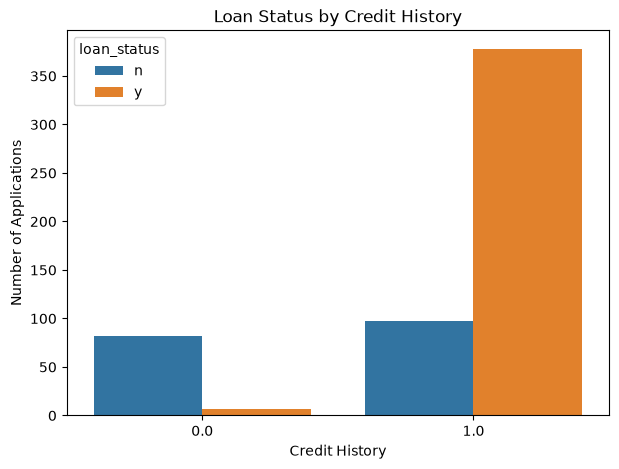

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="credit_history",
    hue="loan_status"
)

plt.title("Loan Status by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Number of Applications")

plt.show()

Education vs Loan Status

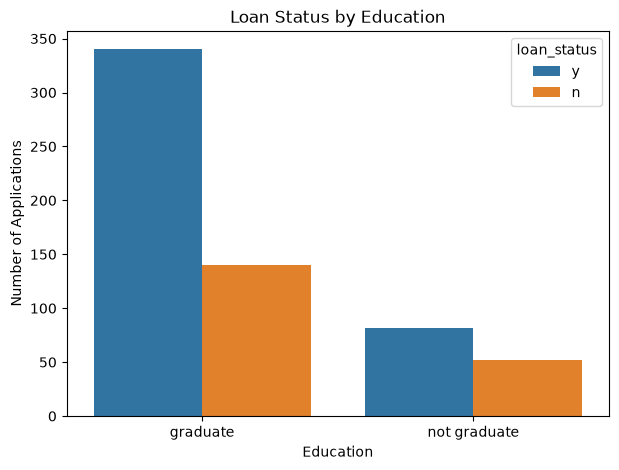

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="education",
    hue="loan_status"
)

plt.title("Loan Status by Education")
plt.xlabel("Education")
plt.ylabel("Number of Applications")

plt.show()

Property Area vs Loan Status

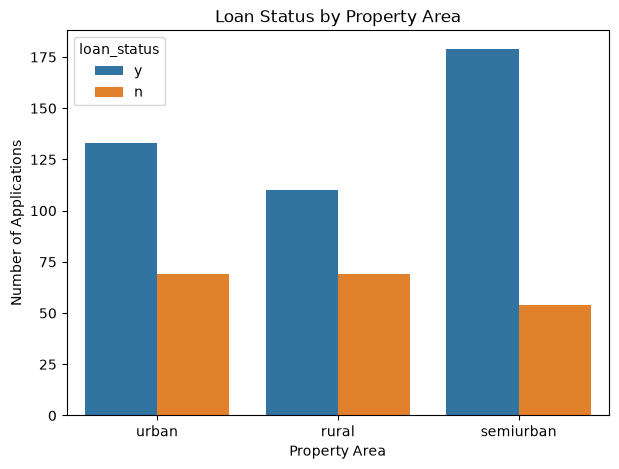

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="property_area",
    hue="loan_status"
)

plt.title("Loan Status by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Number of Applications")

plt.show()

In [17]:
df.columns.tolist()

['loan_id',
 'gender',
 'married',
 'dependents',
 'education',
 'self_employed',
 'applicantincome',
 'coapplicantincome',
 'loanamount',
 'loan_amount_term',
 'credit_history',
 'property_area',
 'loan_status']

In [18]:
df_ml = df.drop("loan_id", axis=1)

In [19]:
df_ml.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y
1,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y
3,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y
4,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y


In [20]:
X = df_ml.drop("loan_status", axis=1)

y = df_ml["loan_status"].map({
    "Y": 1,
    "N": 0
})

In [21]:
y.value_counts()

Series([], Name: count, dtype: int64)

In [22]:
numerical_features = [
    "applicantincome",
    "coapplicantincome",
    "loanamount",
    "loan_amount_term"
]

categorical_features = [
    "gender",
    "married",
    "dependents",
    "education",
    "self_employed",
    "credit_history",
    "property_area"
]

In [23]:
print(df["loan_status"].unique())
print(df["loan_status"].value_counts(dropna=False))

['y' 'n']
loan_status
y    422
n    192
Name: count, dtype: int64


In [24]:
df["loan_status"] = df["loan_status"].astype(str).str.strip().str.upper()

print(df["loan_status"].unique())
print(df["loan_status"].value_counts(dropna=False))

['Y' 'N']
loan_status
Y    422
N    192
Name: count, dtype: int64


In [25]:
df_ml = df.drop("loan_id", axis=1)

X = df_ml.drop("loan_status", axis=1)

y = df_ml["loan_status"].map({
    "Y": 1,
    "N": 0
})

print("Missing values in y:", y.isna().sum())
print(y.value_counts())

Missing values in y: 0
loan_status
1    422
0    192
Name: count, dtype: int64


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 11)
Testing data: (123, 11)


Data Preprocessing

In [28]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [29]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)

Column Transformer

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Logistic Regression

In [31]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [32]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['applicantincome',
                                                   'coapplicantincome',
                                                   'loanamount',
                                                   'loan_amount_term']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'married',
                                                   'dependents', 'education',
                                                   'self_employed',
                                                   'credit_history',
                                                   'property_area'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [33]:
y_pred_lr = logistic_model.predict(X_test)

In [34]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Results
---------------------------
Accuracy : 0.8617886178861789
Precision: 0.84
Recall   : 0.9882352941176471
F1 Score : 0.9081081081081082


Logistic Regression Confusion Matrix

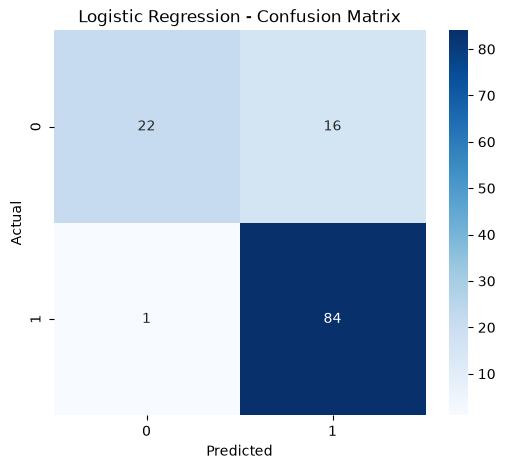

In [35]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [36]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



KNN

In [37]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]
)

In [38]:
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['applicantincome',
                                                   'coapplicantincome',
                                                   'loanamount',
                                                   'loan_amount_term']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'married',
                                                   'dependents', 'education',
                                                   'self_employed',
                                                   'credit_history',
                                                   'property_area'])])),
                ('classifier', KNeighborsClassifier())])

In [39]:
y_pred_knn = knn_model.predict(X_test)

In [40]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("KNN Results")
print("-----------")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

KNN Results
-----------
Accuracy : 0.8130081300813008
Precision: 0.81
Recall   : 0.9529411764705882
F1 Score : 0.8756756756756757


KNN Confusion Matrix

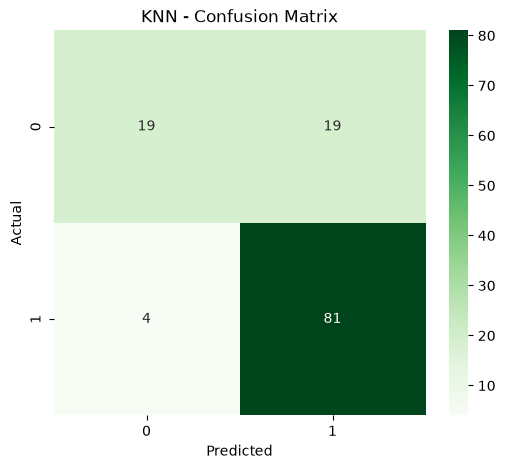

In [41]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.83      0.50      0.62        38
           1       0.81      0.95      0.88        85

    accuracy                           0.81       123
   macro avg       0.82      0.73      0.75       123
weighted avg       0.81      0.81      0.80       123



Comparing Both Models

In [43]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],
    
    "Accuracy": [
        lr_accuracy,
        knn_accuracy
    ],
    
    "Precision": [
        lr_precision,
        knn_precision
    ],
    
    "Recall": [
        lr_recall,
        knn_recall
    ],
    
    "F1 Score": [
        lr_f1,
        knn_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.861789,0.84,0.988235,0.908108
1,KNN,0.813008,0.81,0.952941,0.875676


Comparison Graph

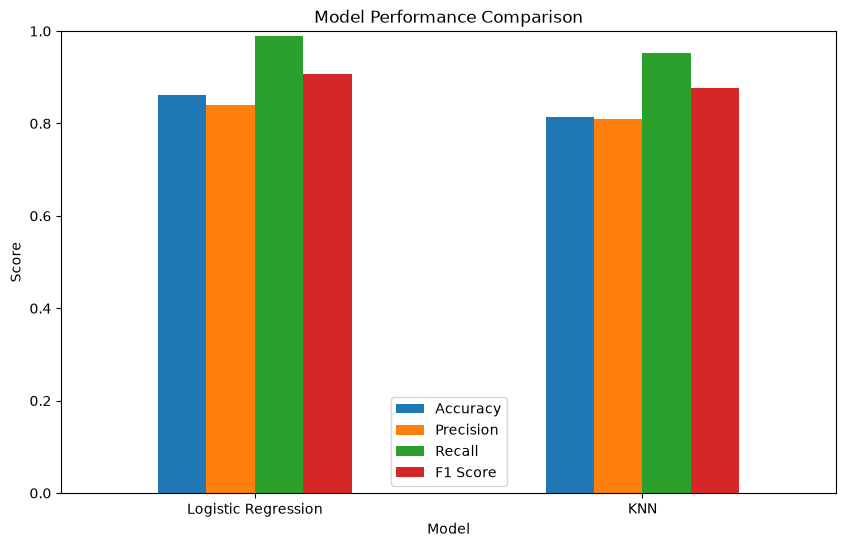

In [44]:
results_plot = results.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

New Applicant Prediction

In [45]:
new_applicant = pd.DataFrame({
    "gender": ["Male"],
    "married": ["Yes"],
    "dependents": ["1"],
    "education": ["Graduate"],
    "self_employed": ["No"],
    "applicantincome": [6000],
    "coapplicantincome": [1500],
    "loanamount": [150],
    "loan_amount_term": [360],
    "credit_history": [1],
    "property_area": ["Semiurban"]
})

new_applicant

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
0,Male,Yes,1,Graduate,No,6000,1500,150,360,1,Semiurban


Predicting Using Logistic Regression

In [46]:
lr_prediction = logistic_model.predict(new_applicant)

lr_result = "Approved" if lr_prediction[0] == 1 else "Rejected"

print("Logistic Regression Prediction:", lr_result)

Logistic Regression Prediction: Approved


c:\Users\Ak\OneDrive\Desktop\Loan_Approval_Project\loan_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 3, 4, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Predicting Using KNN

In [47]:
knn_prediction = knn_model.predict(new_applicant)

knn_result = "Approved" if knn_prediction[0] == 1 else "Rejected"

print("KNN Prediction:", knn_result)

KNN Prediction: Approved


c:\Users\Ak\OneDrive\Desktop\Loan_Approval_Project\loan_env\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1, 3, 4, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Puting Both Predictions Together

In [48]:
prediction_result = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],
    
    "Prediction": [
        lr_result,
        knn_result
    ]
})

prediction_result

,Model,Prediction
0,Logistic Regression,Approved
1,KNN,Approved


In [49]:
results.to_csv("model_results.csv", index=False)

print("Model results saved successfully!")

Model results saved successfully!
